In [107]:
import pandas as pd


In [108]:
df = pd.read_csv('fake_job_postings.csv')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [109]:
df.shape

(17880, 18)

In [110]:
# This show how many job are real or fake
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

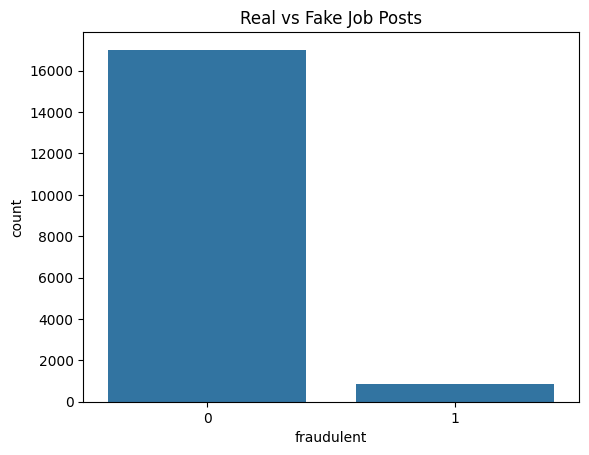

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent',data=df)

plt.title('Real vs Fake Job Posts')
plt.show()

#### Test Cleaning (NLP Preprocessing)

In [112]:
# Combine text Column into one text feature
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['requirements']

In [113]:
df['text'].head()

0    Marketing Intern Food52, a fast-growing, James...
1    Customer Service - Cloud Video Production Orga...
2    Commissioning Machinery Assistant (CMA) Our cl...
3    Account Executive - Washington DC THE COMPANY:...
4    Bill Review Manager JOB TITLE: Itemization Rev...
Name: text, dtype: object

In [114]:
import nltk
import re


from nltk.corpus import stopwords

nltk.download('stopwords')

stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [115]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [116]:
df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [117]:
print(df[['text','clean_text']].head())

                                                text  \
0  Marketing Intern Food52, a fast-growing, James...   
1  Customer Service - Cloud Video Production Orga...   
2  Commissioning Machinery Assistant (CMA) Our cl...   
3  Account Executive - Washington DC THE COMPANY:...   
4  Bill Review Manager JOB TITLE: Itemization Rev...   

                                          clean_text  
0  marketing intern food fast growing james beard...  
1  customer service cloud video production organi...  
2  commissioning machinery assistant cma client l...  
3  account executive washington dc company esri e...  
4  bill review manager job title itemization revi...  


Now we convert text to numerical features.

In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
# Use only the 5000 most important words as feature

x = tfidf.fit_transform(df['clean_text'])

y = df['fraudulent']

In [119]:
x.shape
''' 
Understanding Your Output
(17880, 5000)
Rows → 17880

Number of job postings in the dataset.

Columns → 5000

Number of text features created by TF-IDF.

So the dataset now looks like:

Job 1 → [0.12, 0.00, 0.45, ...]
Job 2 → [0.00, 0.21, 0.10, ...]
'''

' \nUnderstanding Your Output\n(17880, 5000)\nRows → 17880\n\nNumber of job postings in the dataset.\n\nColumns → 5000\n\nNumber of text features created by TF-IDF.\n\nSo the dataset now looks like:\n\nJob 1 → [0.12, 0.00, 0.45, ...]\nJob 2 → [0.00, 0.21, 0.10, ...]\n'

Train the ML Model

In [120]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.26,random_state=42)

In [121]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [122]:
y_pred = model.predict(x_test)

In [123]:
from sklearn.metrics import accuracy_score, classification_report

In [124]:
print('Accuracy: ', accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy:  0.8175951817595182
              precision    recall  f1-score   support

           0       0.99      0.82      0.89      4414
           1       0.20      0.85      0.32       235

    accuracy                           0.82      4649
   macro avg       0.59      0.83      0.61      4649
weighted avg       0.95      0.82      0.87      4649



## Create Prediction Function


In [125]:
def predict_job(text):
    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    # push the vector into predict funtion and get the first value of predict 
    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0][1]

  
    if prediction == 1:
        print("⚠ Fake Job Detected")
    else:
        print("✅ Real Job Posting")

    print('Fake Job Probability:', probability)

In [129]:
predict_job('Earn $5000 weekly working from home data entry job no experience needed apply now')

⚠ Fake Job Detected
Fake Job Probability: 0.9660243717021655


Save Your Model

In [130]:
def find_suspicious_words(text):

    scam_keywords = {
        "earn","weekly","bonus","money","payment",
        "urgent","immediate","investment",
        "click","apply","income","profit","home"
    }

    words = text.lower().split()

    found = []

    for w in words:
        if w in scam_keywords:
            found.append(w)

    return list(set(found))

In [131]:
import joblib

joblib.dump(model, "fake_job_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")



['tfidf_vectorizer.pkl']